# Exercise 3 — Intrinsic vs. post-hoc explainability

**PCS956 • Module C • Week**

## Research question

**What changes when understanding comes directly from a model versus from an additional explanation procedure?**

We compare:

- a small decision tree, inspected directly;
- a Random Forest, which is much harder to inspect as a whole;
- a SHAP explanation applied after the Random Forest is trained.

SHAP is used here only to make the intrinsic/post-hoc distinction concrete. Detailed SHAP methodology is left for the next lecture.


## Dataset: Titanic

We use the same Titanic passenger dataset throughout all four Week 1 practical notebooks so that the **data remain fixed while the explanation question changes**.

Each row represents one passenger. The target is:

- `survived = 1` — the passenger was recorded as surviving;
- `survived = 0` — the passenger was recorded as not surviving.

We use these predictors:

| Feature | Meaning |
|---|---|
| `pclass` | Passenger class: 1st, 2nd, or 3rd |
| `sex` | Recorded sex |
| `age` | Age in years |
| `sibsp` | Number of siblings/spouses aboard |
| `parch` | Number of parents/children aboard |
| `fare` | Passenger fare |
| `embarked` | Port of embarkation |

The seaborn version of the dataset contains missing values, including missing `age` and `embarked` values. Preprocessing is therefore fitted **only on the training data** and then applied to the test data.

### Scientific caution

This is historical observational data. These notebooks investigate **model behaviour**. Feature importance, decision rules, and SHAP attributions should not be interpreted as causal effects on survival.


## 1. Setup and preprocessing


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

RANDOM_STATE = 42

titanic = sns.load_dataset("titanic")

FEATURES = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked"
]
TARGET = "survived"

X = titanic[FEATURES].copy()
y = titanic[TARGET].copy()

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

numeric_features = ["pclass", "age", "sibsp", "parch", "fare"]
categorical_features = ["sex", "embarked"]

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
                drop="if_binary"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    verbose_feature_names_out=False
)

X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)

feature_names = preprocessor.get_feature_names_out()

X_train_df = pd.DataFrame(
    X_train,
    columns=feature_names,
    index=X_train_raw.index
)

X_test_df = pd.DataFrame(
    X_test,
    columns=feature_names,
    index=X_test_raw.index
)

print("Training observations:", len(X_train_df))
print("Test observations:", len(X_test_df))
print("Transformed features:", list(feature_names))

from sklearn.ensemble import RandomForestClassifier


Training observations: 712
Test observations: 179
Transformed features: ['pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_male', 'embarked_C', 'embarked_Q', 'embarked_S']


## 2. Intrinsic model: a small decision tree


In [2]:
small_tree = DecisionTreeClassifier(
    max_depth=3,
    random_state=RANDOM_STATE
)
small_tree.fit(X_train_df, y_train)

tree_pred = small_tree.predict(X_test_df)

tree_metrics = {
    "accuracy": accuracy_score(y_test, tree_pred),
    "balanced_accuracy": balanced_accuracy_score(y_test, tree_pred)
}

print("Decision-tree accuracy:",
      round(tree_metrics["accuracy"], 3))
print("Decision-tree balanced accuracy:",
      round(tree_metrics["balanced_accuracy"], 3))
print("Tree depth:", small_tree.get_depth())
print("Number of nodes:", small_tree.tree_.node_count)


Decision-tree accuracy: 0.793
Decision-tree balanced accuracy: 0.748
Tree depth: 3
Number of nodes: 15


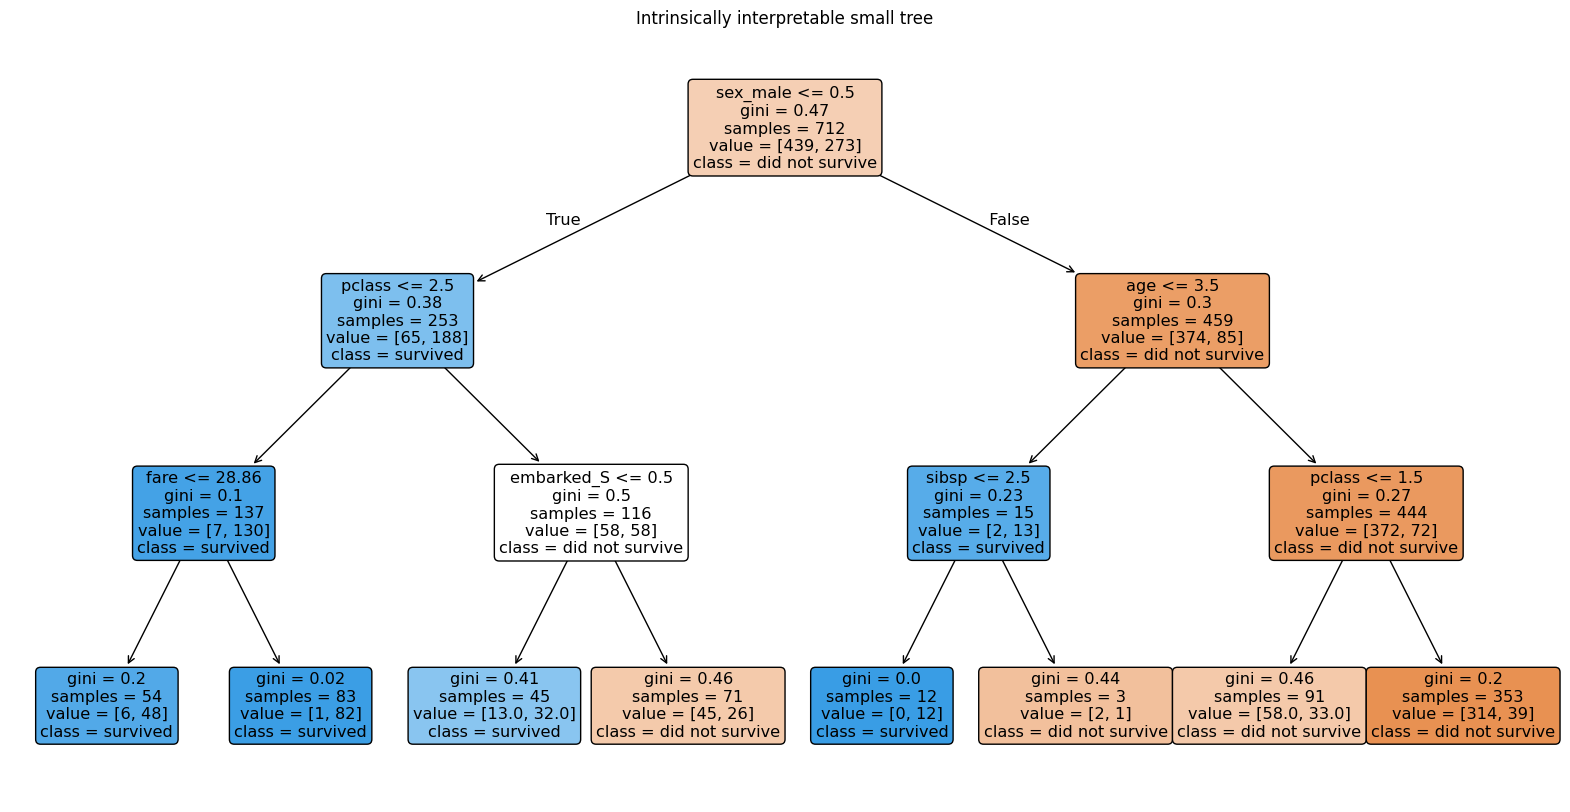

In [3]:
plt.figure(figsize=(20, 10))

plot_tree(
    small_tree,
    feature_names=feature_names,
    class_names=["did not survive", "survived"],
    filled=True,
    rounded=True,
    precision=2
)

plt.title("Intrinsically interpretable small tree")
plt.show()


### Discuss the intrinsic result

The tree's structure, thresholds, and root-to-leaf paths are available by direct inspection.

That does not make the tree automatically correct or scientifically valid; it means relevant aspects of the **fitted model itself** are directly inspectable.


## 3. Harder-to-inspect model: Random Forest

A Random Forest contains many trees. Each tree can technically be inspected, but manually integrating hundreds of tree structures into one human-readable global account is usually impractical.


In [4]:
forest = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

forest.fit(X_train_df, y_train)

forest_pred = forest.predict(X_test_df)

comparison = pd.DataFrame({
    "model": ["Small decision tree", "Random Forest"],
    "accuracy": [
        accuracy_score(y_test, tree_pred),
        accuracy_score(y_test, forest_pred)
    ],
    "balanced_accuracy": [
        balanced_accuracy_score(y_test, tree_pred),
        balanced_accuracy_score(y_test, forest_pred)
    ]
})

display(comparison)


,model,accuracy,balanced_accuracy
0,Small decision tree,0.793296,0.748090
1,Random Forest,0.810056,0.791436


### Discuss the model comparison

Do not assume that the Random Forest must outperform the small tree.

Use the observed metrics to describe this particular split. Then separate the performance question from the interpretability question:

- **small tree:** understanding can come directly from model inspection;
- **Random Forest:** global manual inspection of the whole ensemble is difficult, so an additional explanation procedure may be useful.


## 4. Post-hoc explanation with Tree SHAP

SHAP is applied **after** the Random Forest has been trained.

For scikit-learn `RandomForestClassifier`, current TreeExplainer output contains class-specific attributions. We focus on class `1` (`survived`).

The explanation remains an attribution of **model output**; it is not a causal explanation of survival.


In [5]:
# Uncomment if SHAP is not installed:
# !pip install shap

import shap

explainer = shap.TreeExplainer(forest)
shap_values = explainer(X_test_df)

if shap_values.values.ndim == 3:
    survived_values = shap_values.values[:, :, 1]
    survived_base_values = shap_values.base_values[:, 1]
else:
    survived_values = shap_values.values
    survived_base_values = shap_values.base_values


## 5. Explain one Random-Forest prediction


,pclass,sex,age,sibsp,parch,fare,embarked
565,3,male,24.0,2,0,24.15,S


Random-Forest predicted survival probability: 0.1633


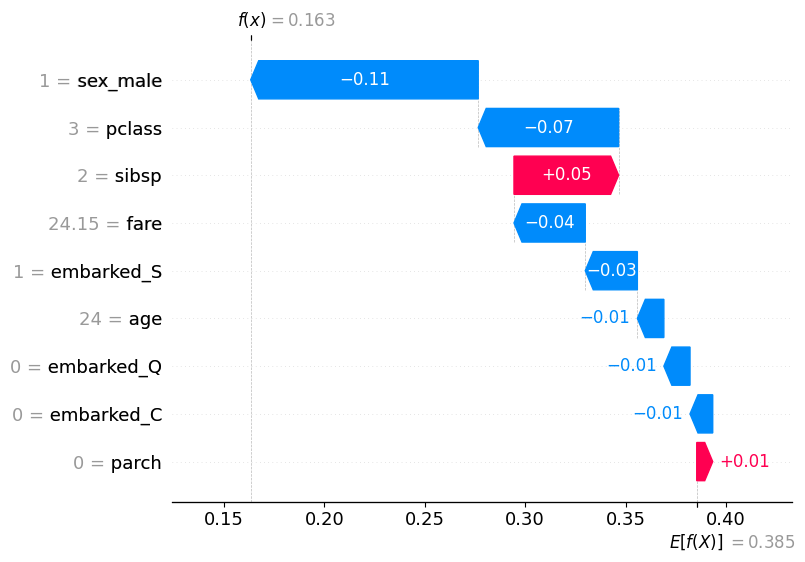

In [6]:
sample_position = 0

raw_sample = X_test_raw.iloc[[sample_position]]
model_sample = X_test_df.iloc[[sample_position]]

predicted_probability = forest.predict_proba(model_sample)[0, 1]

display(raw_sample)

print("Random-Forest predicted survival probability:",
      round(predicted_probability, 4))

local_explanation = shap.Explanation(
    values=survived_values[sample_position],
    base_values=survived_base_values[sample_position]
        if np.ndim(survived_base_values) > 0
        else survived_base_values,
    data=model_sample.iloc[0].values,
    feature_names=list(feature_names)
)

shap.plots.waterfall(local_explanation, max_display=10)


In [7]:
base_value = float(np.asarray(local_explanation.base_values))
attribution_sum = float(np.asarray(local_explanation.values).sum())
reconstructed_output = base_value + attribution_sum

print("Base value:", round(base_value, 6))
print("Sum of SHAP attributions:", round(attribution_sum, 6))
print("Base + attributions:", round(reconstructed_output, 6))
print("Model survival probability:", round(predicted_probability, 6))
print(
    "Additivity check:",
    np.isclose(reconstructed_output, predicted_probability, atol=1e-6)
)


Base value: 0.385412
Sum of SHAP attributions: -0.222079
Base + attributions: 0.163333
Model survival probability: 0.163333
Additivity check: True


### Discuss the post-hoc result

Read the waterfall plot as follows:

- the base value is the explainer's reference model output;
- feature attributions move the selected output away from that reference;
- the attributions add up to the model output for the explained class in this Tree SHAP configuration.

The additivity check is useful, but it does **not** mean that SHAP has revealed the model's full internal reasoning or a real-world causal mechanism.

The Random Forest remains a Random Forest; applying SHAP does not make it intrinsically interpretable.


## 6. Intrinsic and post-hoc approaches side by side

| Intrinsic small tree | Random Forest + post-hoc SHAP |
|---|---|
| Model rules can be inspected directly | An additional procedure is applied after training |
| One tree path is an exact model path | SHAP attributes a selected ensemble output to features |
| Whole structure can be read when the tree is small | Whole ensemble remains difficult to inspect manually |
| No separate explainer is required | Interpretation depends on the explainer and explanation setup |


## Student task

Select one passenger from the test set and compare the two explanation perspectives.

1. For the small decision tree, inspect the exact root-to-leaf path.
2. For the Random Forest, inspect the SHAP explanation for the same passenger.
3. In a short paragraph, explain:

   - which explanation comes directly from the model;
   - which explanation is produced by an additional post-hoc procedure;
   - what each explanation tells you about the fitted model;
   - why applying SHAP does not make the Random Forest intrinsically interpretable.

Detailed SHAP theory is not required in this Week 1 exercise.


## 7. Critical discussion

1. Which statements about the small tree can be verified directly from its structure?
2. What does the SHAP waterfall reveal about the Random Forest output?
3. What does it leave unresolved about the ensemble?
4. Does post-hoc explanation make the Random Forest intrinsically interpretable?
5. Why is SHAP attribution different from causal explanation?
6. If the two models have similar test performance, what other criteria might matter when choosing between them?


## 8. Takeaway

**Intrinsic interpretability** obtains understanding largely through direct inspection of the model itself.

**Post-hoc explainability** adds an explanation procedure after training to investigate model behaviour or predictions.

Post-hoc explanation can provide useful evidence about a difficult-to-inspect model without transforming that model into an intrinsically interpretable one.
